[INFO] 4 baris kosong/tidak lengkap dibuang otomatis.
[INFO] Total data setelah dibersihkan & digabung: 300 baris
Label
Waspada    150
Bahaya      90
Aman        60
Name: count, dtype: int64

[PERINGATAN] Distribusi kelas tidak seimbang (rasio 2.5x antara kelas terbanyak 'Waspada' dan tersedikit 'Aman').
             Model otomatis diberi class_weight='balanced' untuk mengompensasi,
             tapi idealnya jumlah sampel per kelas dibuat lebih rata saat
             pengumpulan data berikutnya.

[HASIL] Cross-validation accuracy (5-fold): [0.93333333 0.91666667 0.93333333 0.91666667 0.95      ]
[HASIL] Rata-rata akurasi: 93.00%

[HASIL] Classification report (test set):
              precision    recall  f1-score   support

        Aman       0.92      0.92      0.92        12
      Bahaya       0.87      0.72      0.79        18
     Waspada       0.82      0.90      0.86        30

    accuracy                           0.85        60
   macro avg       0.87      0.85      0.85    

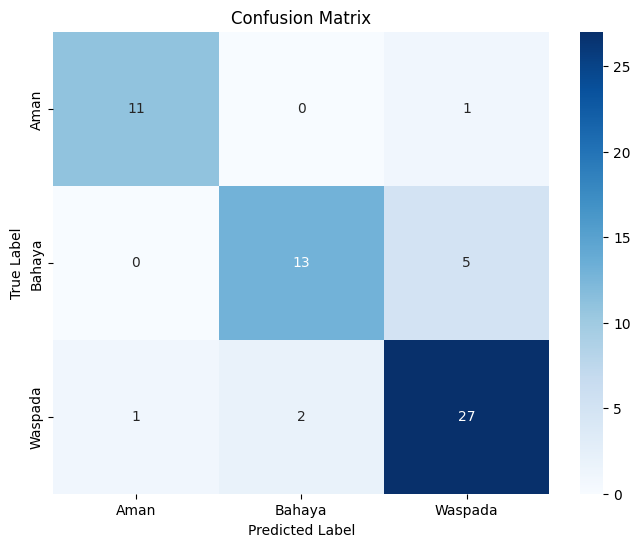


[OK] rf_model.h berhasil di-generate ulang (9 pohon).
     Salin file ini ke folder receiver_edge_gateway, lalu upload ulang.


In [ ]:
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== KONFIGURASI ======================
N_ESTIMATORS = 9      # jumlah pohon -- naikkan kalau dataset makin besar/variatif
MAX_DEPTH = 3          # kedalaman tiap pohon -- jaga kecil agar tetap ringan di ESP32
RANDOM_STATE = 42
OUTPUT_HEADER = "rf_model.h"

FEATURES = [
    "Hujan ADC", "Hujan %", "Soil ADC", "Soil %",
    "accel_magnitude", "gyro_magnitude", "pitch", "roll",
]

# Mapping nama kolom dataset -> nama variabel di kode C (HARUS sama dengan
# parameter classifyRiskRF() di receiver_edge_gateway.ino)
CVAR = {
    "Hujan ADC": "rainADC",
    "Hujan %": "rainPct",
    "Soil ADC": "soilADC",
    "Soil %": "soilPct",
    "accel_magnitude": "accelMag",
    "gyro_magnitude": "gyroMag",
    "pitch": "pitch",
    "roll": "roll",
}

# Urutan kelas HARUS konsisten dengan riskClassToString() di rf_model.h
# (LabelEncoder akan urutkan alfabetis: Aman=0, Bahaya=1, Waspada=2)
EXPECTED_CLASS_ORDER = ["Aman", "Bahaya", "Waspada"]


def load_dataset(paths):
    dfs = []
    for p in paths:
        df = pd.read_csv(p, sep=None, engine="python", decimal=",")
        df.columns = [c.strip() for c in df.columns]
        dfs.append(df)
    full = pd.concat(dfs, ignore_index=True)

    # --- Bersihkan baris kosong / tidak lengkap (umum terjadi karena baris
    # kosong nyangkut di akhir file CSV saat export dari Excel/Sheets) ---
    before = len(full)
    required_cols = FEATURES + ["Label"]
    full = full.dropna(subset=required_cols).reset_index(drop=True)
    removed = before - len(full)
    if removed > 0:
        print(f"[INFO] {removed} baris kosong/tidak lengkap dibuang otomatis.")

    # --- Cek duplikat exact (boleh saja terjadi wajar pada sensor ADC,
    # tapi tetap diinfokan untuk transparansi) ---
    dup_count = full.duplicated(subset=required_cols).sum()
    if dup_count > 0:
        print(f"[INFO] Ditemukan {dup_count} baris duplikat persis (tidak dibuang otomatis).")

    print(f"[INFO] Total data setelah dibersihkan & digabung: {len(full)} baris")
    counts = full["Label"].value_counts()
    print(counts)

    # --- Peringatan ketidakseimbangan kelas ---
    if len(counts) > 0:
        ratio = counts.max() / counts.min()
        if ratio >= 1.5:
            print(f"\n[PERINGATAN] Distribusi kelas tidak seimbang (rasio {ratio:.1f}x antara "
                  f"kelas terbanyak '{counts.idxmax()}' dan tersedikit '{counts.idxmin()}').")
            print("             Model otomatis diberi class_weight='balanced' untuk mengompensasi,")
            print("             tapi idealnya jumlah sampel per kelas dibuat lebih rata saat")
            print("             pengumpulan data berikutnya.")

    return full


def evaluate_model(X, y, class_names):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rf = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    scores = cross_val_score(rf, X, y, cv=skf)
    print(f"\n[HASIL] Cross-validation accuracy (5-fold): {scores}")
    print(f"[HASIL] Rata-rata akurasi: {scores.mean()*100:.2f}%")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    rf_eval = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    rf_eval.fit(X_train, y_train)
    pred = rf_eval.predict(X_test)

    print("\n[HASIL] Classification report (test set):")
    print(classification_report(y_test, pred, target_names=class_names))

    cm = confusion_matrix(y_test, pred)
    print("[HASIL] Confusion matrix (baris=aktual, kolom=prediksi):")
    print(class_names)
    print(cm)

    # Visualize the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    if scores.mean() < 0.85:
        print("\n[PERINGATAN] Akurasi cross-validation di bawah 85%.")
        print("  -> Pertimbangkan tambah data, cek label yang mungkin salah,")
        print("     atau tambah N_ESTIMATORS/MAX_DEPTH sedikit.")


def gen_tree_code(tree, func_name):
    t = tree.tree_
    lines = [
        f"int {func_name}(int rainADC, int rainPct, int soilADC, int soilPct, "
        f"float accelMag, float gyroMag, float pitch, float roll) {{"
    ]

    def recurse(node, depth):
        indent = "  " * (depth + 1)
        if t.feature[node] != -2:  # bukan leaf
            fname = CVAR[FEATURES[t.feature[node]]]
            thresh = t.threshold[node]
            lines.append(f"{indent}if ({fname} <= {thresh:.3f}f) {{")
            recurse(t.children_left[node], depth + 1)
            lines.append(f"{indent}}} else {{")
            recurse(t.children_right[node], depth + 1)
            lines.append(f"{indent}}})")
        else:
            cls = int(np.argmax(t.value[node][0]))
            lines.append(f"{indent}return {cls};")

    recurse(0, 0)
    lines.append("}")
    return "\n".join(lines)


def generate_header(rf, class_names, n_samples):
    tree_codes = [
        gen_tree_code(est, f"treeVote_{i}") for i, est in enumerate(rf.estimators_)
    ]
    n_trees = len(rf.estimators_)

    vote_calls = "\n".join(
        f"  votes[treeVote_{i}(rainADC, rainPct, soilADC, soilPct, accelMag, "
        f"gyroMag, pitch, roll)]++;"
        for i in range(n_trees)
    )

    class_switch = "\n".join(
        f"    case {i}: return \"{name.upper()}\";" for i, name in enumerate(class_names)
    )

    header = f'''/*
  =====================================================================
  TANAALERT - MODEL RANDOM FOREST (rf_model.h)
  =====================================================================
  File ini di-generate OTOMATIS oleh train_and_generate.py

  Konfigurasi training:
    - Jumlah data latih : {n_samples} sampel
    - n_estimators       : {n_trees} pohon
    - max_depth          : {MAX_DEPTH}

  Mapping kelas (urutan ini ditentukan otomatis oleh LabelEncoder,
  JANGAN diubah manual):
{chr(10).join(f"    {i} = {name}" for i, name in enumerate(class_names))}
  =====================================================================
*/

#ifndef RF_MODEL_H
#define RF_MODEL_H

// ====================== {n_trees} POHON KEPUTUSAN (HASIL TRAINING) ======================

{chr(10).join(tree_codes)}

// ====================== VOTING (RANDOM FOREST) ======================
int classifyRiskRF(int rainADC, int rainPct, int soilADC, int soilPct,
                    float accelMag, float gyroMag, float pitch, float roll) {{
  int votes[{len(class_names)}] = {{{", ".join(["0"] * len(class_names))}}};

{vote_calls}

  int bestClass = 0;
  for (int i = 1; i < {len(class_names)}; i++) {{
    if (votes[i] > votes[bestClass]) bestClass = i;
  }}
  return bestClass;
}}

inline String riskClassToString(int riskClass) {{
  switch (riskClass) {{
{class_switch}
    default: return "UNKNOWN";
  }}
}}

#endif
'''
    with open(OUTPUT_HEADER, "w") as f:
        f.write(header)
    print(f"\n[OK] {OUTPUT_HEADER} berhasil di-generate ulang ({n_trees} pohon).")
    print("     Salin file ini ke folder receiver_edge_gateway, lalu upload ulang.")


def main():
    # In a Colab environment, sys.argv can contain kernel-specific arguments
    # that are not actual file paths. We will directly provide the known dataset.
    # For command-line execution, the original `sys.argv[1:]` would be appropriate.
    dataset_paths = ["/content/dataset_sensor_300sampel.csv"] # Explicitly provide the dataset path

    # Optional: If you need to handle command-line arguments in a more robust way
    # in a mixed environment, you might filter sys.argv:
    # actual_args = [arg for arg in sys.argv[1:] if not arg.startswith('-') and arg.endswith('.csv')]
    # if not actual_args:
    #     print("Pakai: python train_and_generate.py dataset1.csv [dataset2.csv ...]")
    #     sys.exit(1)
    # df = load_dataset(actual_args)

    df = load_dataset(dataset_paths)
    X = df[FEATURES].values

    le = LabelEncoder()
    y = le.fit_transform(df["Label"].values)
    class_names = list(le.classes_)

    if class_names != EXPECTED_CLASS_ORDER:
        print(f"[PERINGATAN] Urutan label terdeteksi: {class_names}")
        print(f"             (Biasanya: {EXPECTED_CLASS_ORDER})")
        print("             Pastikan riskClassToString() di kode C tetap sesuai urutan ini.")

    evaluate_model(X, y, class_names)

    # Latih model FINAL pakai SELURUH data (bukan cuma 80% training split)
    global rf_final # Declare rf_final as a global variable
    rf_final = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    rf_final.fit(X, y)

    generate_header(rf_final, class_names, len(df))


if __name__ == "__main__":
    main()

/tmp/ipykernel_1813/822167331.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


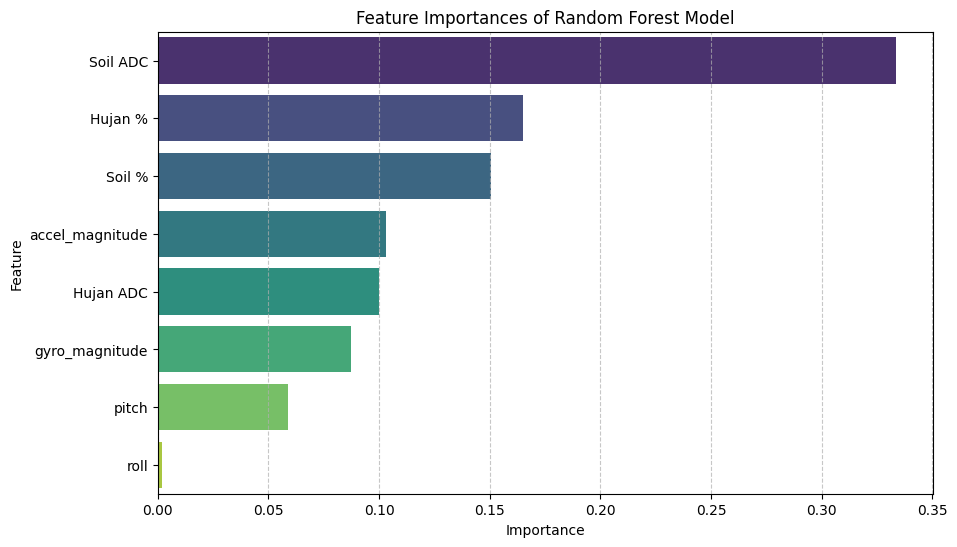

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming rf_final is the final trained model from the previous cell
# If rf_final is not available, we can use rf_eval from evaluate_model function.
# For simplicity and consistency with the previous run, we'll assume rf_final is available after main().

# Get feature importances
feature_importances = rf_final.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances of Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Install graphviz library if not already installed
!pip install graphviz

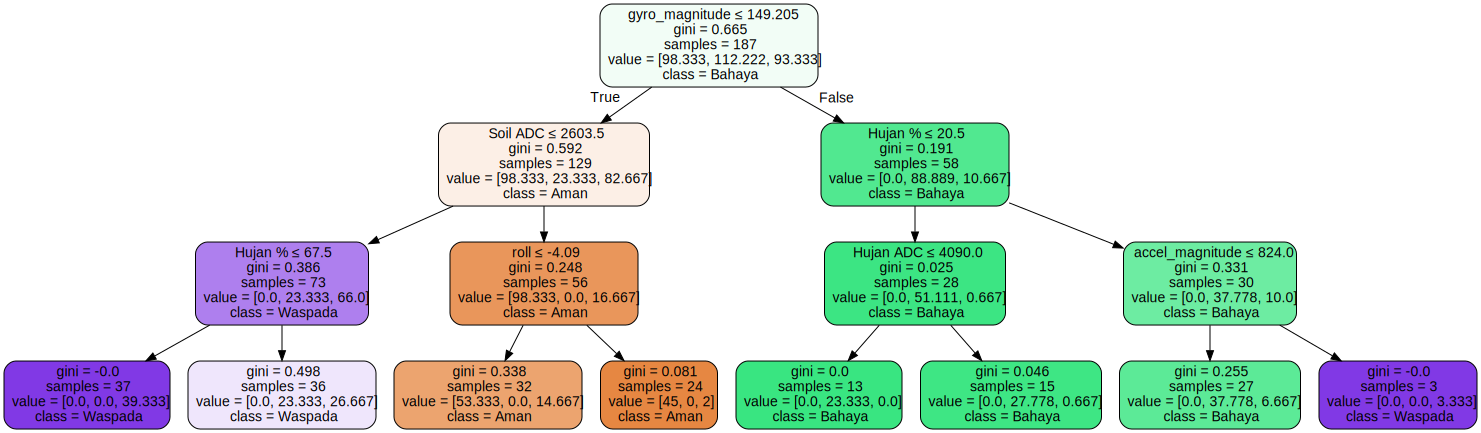

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Take one tree from the Random Forest (e.g., the first tree)
estimator = rf_final.estimators_[0]

# Export the tree to a DOT file
dot_data = export_graphviz(estimator,
                           feature_names=FEATURES,
                           class_names=EXPECTED_CLASS_ORDER, # Use the actual class names
                           filled=True, rounded=True,
                           special_characters=True,
                           out_file=None)

# Render the DOT graph as an image
graph = graphviz.Source(dot_data)
graph.render("decision_tree", format="png", cleanup=True) # Save as PNG and clean up dot file

# Display the graph
graph

This visualization shows the first decision tree within your Random Forest model. Each node represents a decision based on a feature, and the leaves represent the final predicted class. The color intensity indicates the purity of the node (how homogeneous the samples are in that node).